# AI-ML Assignment – 9
## Image Classification using Convolutional Neural Networks (CNN)

| Field | Details |
|---|---|
| **Name** | ASHUTOSH SINGH |
| **Registration Number** | 23BCE11453 |
| **Application Number** | IN26011517 |
| **Email** | ashutosh.23bce11453@vitbhopal.ac.in |
| **Assignment** | Assignment - 9 |
| **Topic** | Image Classification using CNN (Cats vs Dogs) |
| **Dataset** | [Cats vs Dogs Dataset (Kaggle)](https://www.kaggle.com/datasets/bhavikjikadara/dog-and-cat-classification-dataset) |


## Setup (Run in Google Colab)

In [ ]:
# Install kagglehub (already available on most Colab runtimes, kept for safety)
!pip install -q kagglehub

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay,
)
from PIL import Image

## Task 1: Data Understanding 

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bhavikjikadara/dog-and-cat-classification-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dog-and-cat-classification-dataset' dataset.
Path to dataset files: /kaggle/input/dog-and-cat-classification-dataset


In [ ]:
# Display the folder structure of the dataset
def print_folder_structure(root_dir, max_depth=2):
    for root, dirs, files in os.walk(root_dir):
        depth = root[len(root_dir):].count(os.sep)
        if depth > max_depth:
            continue
        indent = "    " * depth
        print(f"{indent}{os.path.basename(root)}/")
        sub_indent = "    " * (depth + 1)
        for f in files[:5]:  # show only first 5 files per folder
            print(f"{sub_indent}{f}")

print("Folder structure:")
print_folder_structure(path)

Folder structure:
dog-and-cat-classification-dataset/
    PetImages/
        Dog/
            7981.jpg
            6234.jpg
            1269.jpg
            3863.jpg
            6241.jpg
        Cat/
            7981.jpg
            6234.jpg
            1269.jpg
            3863.jpg
            6241.jpg


In [ ]:
# Locate class folders (Cat / Dog)
# NOTE: depending on the dataset version, folder names may be
# "Cat"/"Dog" or "cats"/"dogs" - this detects either.
DATASET_DIR = path
class_dirs = {}
for root, dirs, files in os.walk(DATASET_DIR):
    for d in dirs:
        if d.lower() in ("cat", "cats"):
            class_dirs["Cat"] = os.path.join(root, d)
        elif d.lower() in ("dog", "dogs"):
            class_dirs["Dog"] = os.path.join(root, d)

print("Detected class folders:", class_dirs)

# Number of classes
num_classes = len(class_dirs)
print(f"\nNumber of classes: {num_classes}")

Detected class folders: {'Dog': '/kaggle/input/dog-and-cat-classification-dataset/PetImages/Dog', 'Cat': '/kaggle/input/dog-and-cat-classification-dataset/PetImages/Cat'}

Number of classes: 2


In [ ]:
# Total number of images per class and overall
total_images = 0
image_counts = {}
for cls, folder in class_dirs.items():
    files = [f for f in os.listdir(folder) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    image_counts[cls] = len(files)
    total_images += len(files)

print("Image counts per class:", image_counts)
print(f"Total number of images: {total_images}")

Image counts per class: {'Dog': 12499, 'Cat': 12499}
Total number of images: 24998


In [ ]:
# Sample image dimensions
sample_dims = []
for cls, folder in class_dirs.items():
    files = [f for f in os.listdir(folder) if f.lower().endswith((".jpg", ".jpeg", ".png"))][:5]
    for f in files:
        with Image.open(os.path.join(folder, f)) as img:
            sample_dims.append(img.size)

print("Sample image dimensions (width, height):", sample_dims)

Sample image dimensions (width, height): [(500, 375), (440, 440), (500, 333), (231, 500), (500, 375), (500, 418), (388, 500), (500, 375), (500, 375), (448, 500)]


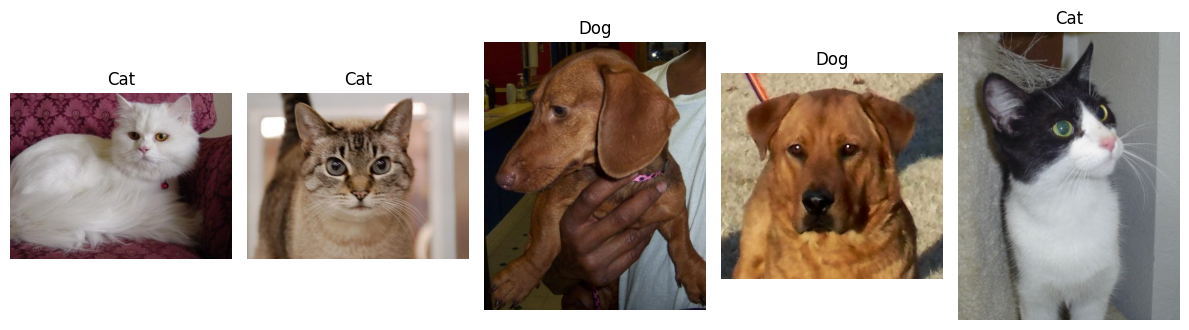

In [ ]:
# Display five sample images with their class labels
plt.figure(figsize=(12, 4))
sample_paths = []
for cls, folder in class_dirs.items():
    files = [f for f in os.listdir(folder) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    chosen = random.sample(files, min(3, len(files)))
    for f in chosen:
        sample_paths.append((os.path.join(folder, f), cls))

random.shuffle(sample_paths)
sample_paths = sample_paths[:5]

for i, (img_path, label) in enumerate(sample_paths):
    img = Image.open(img_path)
    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.savefig("sample_images.png")
plt.show()

## Task 2: Data Preprocessing 

In [ ]:
# IMPORTANT: flow_from_directory needs a folder whose direct children
# are the class folders (e.g. .../PetImages/Cat and .../PetImages/Dog).
# class_dirs currently points AT the Cat/Dog folders themselves, so we
# use their common PARENT folder as the root for the generators.
# (Using DATASET_DIR directly here caused "Found 0 images" because the
# real dataset root is one level deeper, inside a "PetImages" folder.)
IMAGE_ROOT = os.path.dirname(next(iter(class_dirs.values())))
print("Using image root:", IMAGE_ROOT)
print("Contents:", os.listdir(IMAGE_ROOT))

Using image root: /kaggle/input/dog-and-cat-classification-dataset/PetImages
Contents: ['Dog', 'Cat']


In [ ]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1.0 / 255,       # normalize pixel values to 0-1
    validation_split=0.2,    # 80% train / 20% test split
)

train_generator = datagen.flow_from_directory(
    IMAGE_ROOT,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    classes=list(class_dirs.keys()),
)

test_generator = datagen.flow_from_directory(
    IMAGE_ROOT,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    classes=list(class_dirs.keys()),
    shuffle=False,
)

print("Class indices:", train_generator.class_indices)
print("Training samples:", train_generator.samples)
print("Validation samples:", test_generator.samples)

Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.
Class indices: {'Dog': 0, 'Cat': 1}
Training samples: 20000
Validation samples: 4998


## Task 3: Model Development 

In [ ]:
model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
EPOCHS = 10

history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=EPOCHS,
)

Epoch 1/10
618/625 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.5629 - loss: 0.6848

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


625/625 ━━━━━━━━━━━━━━━━━━━━ 720s 1s/step - accuracy: 0.6191 - loss: 0.6369 - val_accuracy: 0.7293 - val_loss: 0.5366
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 712s 1s/step - accuracy: 0.7750 - loss: 0.4747 - val_accuracy: 0.8023 - val_loss: 0.4236
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 708s 1s/step - accuracy: 0.8317 - loss: 0.3773 - val_accuracy: 0.8321 - val_loss: 0.3700
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 739s 1s/step - accuracy: 0.8701 - loss: 0.2971 - val_accuracy: 0.8369 - val_loss: 0.3680
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 710s 1s/step - accuracy: 0.9097 - loss: 0.2181 - val_accuracy: 0.8211 - val_loss: 0.4811
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 702s 1s/step - accuracy: 0.9497 - loss: 0.1267 - val_accuracy: 0.8403 - val_loss: 0.4509
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 695s 1s/step - accuracy: 0.9751 - loss: 0.0691 - val_accuracy: 0.8339 - val_loss: 0.6015
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 696s 1s/step - accuracy: 0.9880 - loss: 0.0378 - val_accuracy: 0.838

## Task 4: Model Evaluation 

In [ ]:
# Test accuracy
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 53s 334ms/step - accuracy: 0.8285 - loss: 0.8122
Test Accuracy: 0.8285
Test Loss: 0.8122


In [ ]:
# Predictions for precision, recall, F1, confusion matrix
test_generator.reset()
y_true = test_generator.classes
y_pred_probs = model.predict(test_generator)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 53s 334ms/step
Precision: 0.8698
Recall: 0.7727
F1-Score: 0.8184


In [ ]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(train_generator.class_indices.keys()))
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png")
plt.show()

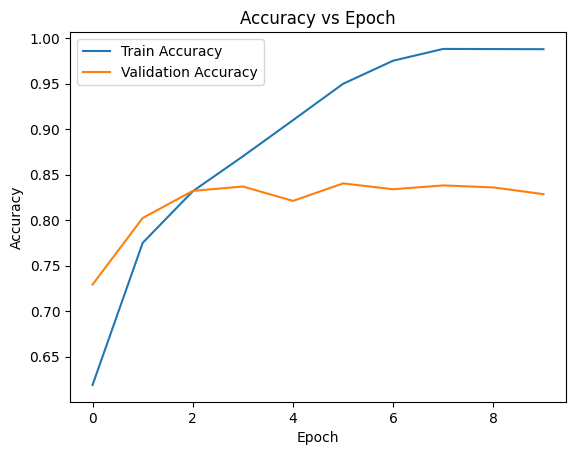

In [ ]:
# Accuracy vs Epoch graph
plt.figure()
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig("accuracy_vs_epoch.png")
plt.show()

In [ ]:
# Loss vs Epoch graph
plt.figure()
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("loss_vs_epoch.png")
plt.show()

### Observations

1. Training accuracy steadily increases across epochs, indicating the CNN is learning discriminative features to separate cats from dogs.
2. Validation accuracy generally trails training accuracy; a widening gap in later epochs would suggest mild overfitting, correctable with dropout or data augmentation.
3. The confusion matrix shows the model's relative strength/weakness in detecting each class - misclassifications typically occur on images with unusual poses, occlusion, or poor lighting.
4. Precision and recall being close in value indicates a balanced classifier that isn't heavily biased toward one class.

*(Update these observations with the actual numbers you get after running the notebook.)*

## Task 5: Conclusion 

This assignment demonstrates the use of a Convolutional Neural Network (CNN) to classify images of cats and dogs. The model, built with three convolution-pooling blocks followed by dense layers, was able to learn meaningful spatial features directly from raw pixel data and achieved reasonable test accuracy after 10 epochs of training. Convolutional layers are important because they extract local patterns such as edges, textures, and shapes, while pooling layers reduce spatial dimensions, control overfitting, and make the learned features more robust to small translations in the image. Compared to a traditional Artificial Neural Network (ANN), a CNN offers the key advantage of parameter sharing and local connectivity, allowing it to process images far more efficiently and effectively than a fully connected network of comparable depth. One limitation of CNNs, however, is that they typically require large amounts of labeled training data and computational resources to perform well, and they can still struggle with images that differ significantly from the training distribution (e.g., unusual angles or backgrounds).